# Investigating a Deployed ML Model via API (Phase 4)

- Author: Venkat Teja
- Date: 2026-08
- API: ML Penguin Predictor
- Endpoint: https://ml-penguin-predictor.onrender.com/predict
- Target: species

This is my copy of `ml_07_case.ipynb` for **Phase 4**

## What This Notebook Does

The model is already trained and served, so I cannot see inside it.
I probe it from the outside: vary inputs, watch the predictions change,
and name what that implies about the model.

## My Phase 4 Change

The example sweeps **one** feature (`bill_length_mm`) and asks which feature
produces the sharpest boundary - but it never answers that question,
because it only ever varies one.

**I added Section 3b:** the same `sweep_feature()` function applied to
**all four** features over their realistic ranges, plotted as small multiples
and ranked by how much each feature moves the prediction. That turns
"which input matters most?" from a guess into a measurement.

Measuring instead of eyeballing then caught three things the example reports
incorrectly, so I fixed each one:

1. **A false `MISMATCH`.** The example's 30-second timeout is shorter than a
   cold start on this free-tier host (measured: ~50s), so the first baseline
   call timed out and was scored as a wrong prediction. I raised the timeout
   and warm the server up before the baseline check.
2. **A fake decision boundary.** On my first full run one dropped connection
   mid-sweep left an error string where a species should have been, and my own
   boundary detector counted it as a boundary. Transient failures are now
   retried; an HTTP 4xx is the server's real answer and is never retried.
3. **A mislabeled heatmap.** Section 3b proved Gentoo is never predicted from
   this baseline, yet the example's grid showed large seagreen regions - the
   color its title assigns to Gentoo. Details and the two-argument fix are in
   Section 4.

Plus one editor-level fix: `sweep_feature()` declared `values: list[float]`,
which rejects the numpy floats `np.linspace()` actually produces. Section 3
explains the one-word fix.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from collections.abc import Sequence  # covariant, so it accepts numpy floats
from importlib.metadata import version  # to verify
import logging  # for type hinting
from pathlib import Path  # to save figures for the README and docs
import platform  # to verify
import time  # brief backoff between retries
from typing import Any  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M07_TEJA", level="DEBUG")
log_header(LOG, "M07_TEJA")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  requests:     {version('requests')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# === Section 1e. GLOBAL CONSTANTS ===

API_URL: str = "https://ml-penguin-predictor.onrender.com/predict"

# MY CHANGE: the example used timeout=30, but a cold start on this free-tier
# host takes longer than that, so the first call failed and reported a false
# MISMATCH. Measured cold start: about 50 seconds.
REQUEST_TIMEOUT_S: int = 90

# MY CHANGE: retry transient network failures so one dropped connection is not
# mistaken for a change in the model's prediction.
MAX_ATTEMPTS: int = 3

# Charts are saved here so the README and docs can show them.
IMAGES_DIR: Path = Path("..") / "docs" / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# Shared species styling, used by every chart in this notebook.
SPECIES_ORDER: list[str] = ["Adelie", "Chinstrap", "Gentoo"]
COLOR_MAP: dict[str, str] = {
    "Adelie": "steelblue",
    "Chinstrap": "tomato",
    "Gentoo": "seagreen",
}

LOG.info(f"API endpoint: {API_URL}")
LOG.info(f"Request timeout: {REQUEST_TIMEOUT_S}s")
LOG.info(f"Images directory: {IMAGES_DIR.resolve()}")

2026-08-14 00:47:41 | INFO | M07_TEJA | === RUN START ===


2026-08-14 00:47:41 | INFO | M07_TEJA | project=M07_TEJA


2026-08-14 00:47:41 | INFO | M07_TEJA | repo_dir=ml-07-applied


2026-08-14 00:47:41 | INFO | M07_TEJA | python=3.14.0


2026-08-14 00:47:41 | INFO | M07_TEJA | os=Windows 11


...

2026-08-14 00:47:41 | INFO | M07_TEJA |   seaborn:      0.13.2


2026-08-14 00:47:41 | INFO | M07_TEJA |   requests:     2.34.2


2026-08-14 00:47:41 | INFO | M07_TEJA | API endpoint: https://ml-penguin-predictor.onrender.com/predict


2026-08-14 00:47:41 | INFO | M07_TEJA | Request timeout: 90s


2026-08-14 00:47:41 | INFO | M07_TEJA | Images directory: C:\GitHub_Repo\ml-07-applied\docs\images


## Section 2. Baseline Predictions

Before investigating, confirm the API returns the expected species for three
known penguins - one per species. If these baseline calls fail, nothing
downstream can be trusted.

**My change here:** a hardened `predict()` - longer timeout, a warm-up call,
and retries on transient failures - so a sleeping or flaky server is not
mistaken for a wrong prediction.

In [2]:
# === Section 2. Baseline Predictions ===


def predict(payload: dict[str, Any]) -> str:
    """Send a payload to the prediction API and return the predicted species.

    WHY: A single reusable function keeps all API calls consistent.
    Any change to the endpoint or headers only needs to happen here.

    MY CHANGE: retry transient network failures. A dropped connection is not
    an answer from the model, and on my first run one connection reset in the
    middle of a sweep looked exactly like a decision boundary. An HTTP 4xx is
    a real answer (the server rejected the input), so it is never retried.

    Args:
        payload: dict of feature name -> value.

    Returns:
        Predicted species string, or an error message string.
    """
    last_error: str = "unknown"
    for attempt in range(1, MAX_ATTEMPTS + 1):
        try:
            response = requests.post(API_URL, json=payload, timeout=REQUEST_TIMEOUT_S)
            response.raise_for_status()
            return str(response.json().get("prediction", "NO_PREDICTION_KEY"))
        except requests.exceptions.HTTPError as exc:
            return f"ERROR: {exc}"  # the server's real answer; do not retry
        except requests.exceptions.RequestException as exc:
            last_error = str(exc)
            if attempt < MAX_ATTEMPTS:
                time.sleep(2 * attempt)  # brief backoff, then try again
    return f"ERROR after {MAX_ATTEMPTS} attempts: {last_error}"


# One known example per species from the penguins dataset.
BASELINES: list[dict[str, Any]] = [
    {
        "bill_length_mm": 39.1,
        "bill_depth_mm": 18.7,
        "flipper_length_mm": 181,
        "body_mass_g": 3750,
    },
    {
        "bill_length_mm": 46.5,
        "bill_depth_mm": 17.9,
        "flipper_length_mm": 192,
        "body_mass_g": 3500,
    },
    {
        "bill_length_mm": 46.1,
        "bill_depth_mm": 13.2,
        "flipper_length_mm": 211,
        "body_mass_g": 4500,
    },
]
EXPECTED: list[str] = ["Adelie", "Chinstrap", "Gentoo"]

# MY CHANGE: warm the server up first so the cold start is not counted
# against the first baseline penguin.
LOG.info("Warming up the API (a sleeping free-tier server can take ~50s)...")
warmup_result = predict(BASELINES[0])
LOG.info(f"Warm-up response: {warmup_result}")

LOG.info("Baseline predictions:")
for payload, expected in zip(BASELINES, EXPECTED, strict=True):
    result = predict(payload)
    match = "OK" if result == expected else "MISMATCH"
    LOG.info(f"  expected={expected:<10} got={result:<10} [{match}]")

2026-08-14 00:47:41 | INFO | M07_TEJA | Warming up the API (a sleeping free-tier server can take ~50s)...


2026-08-14 00:47:42 | INFO | M07_TEJA | Warm-up response: Adelie


2026-08-14 00:47:42 | INFO | M07_TEJA | Baseline predictions:


2026-08-14 00:47:43 | INFO | M07_TEJA |   expected=Adelie     got=Adelie     [OK]


2026-08-14 00:47:44 | INFO | M07_TEJA |   expected=Chinstrap  got=Chinstrap  [OK]


2026-08-14 00:47:44 | INFO | M07_TEJA |   expected=Gentoo     got=Gentoo     [OK]


## Section 3. Feature Sensitivity (One Feature)

Vary one feature at a time while holding the others fixed. Where the
prediction changes is the model's decision boundary for that feature.

This section is the example's, with two typing fixes that clear the red
squiggles the example shows in VS Code:

- `sweep_feature()` declared `values: list[float]`, but `np.linspace()` returns
  numpy floats. `list` is **invariant**, so `list[np.float64]` is not a
  `list[float]` even though `np.float64` subclasses `float`. Widening the
  parameter to `Sequence[float]`, which is **covariant**, fixes every call site
  at once and leaves the call sites byte-identical to the example.
- `Series.map()` accepts a dict at runtime - the example relies on it and it
  works - but the stubs type the argument as callable-only. That one is a stub
  limitation rather than a real defect, so it gets an inline
  `# pyright: ignore`, the same idiom the example already uses for
  `plt.Line2D`.

Neither changes behavior; the outputs below are identical either way.

2026-08-14 00:48:09 | INFO | M07_TEJA | bill_length_mm sweep:


2026-08-14 00:48:09 | INFO | M07_TEJA |  bill_length_mm prediction
      30.000000     Adelie
      31.578947     Adelie
      33.157895     Adelie
      34.736842     Adelie
      36.315789     Adelie
      37.894737     Adelie
      39.473684     Adelie
      41.052632     Adelie
      42.631579  Chinstrap
      44.210526  Chinstrap
      45.789474  Chinstrap
      47.368421  Chinstrap
      48.947368  Chinstrap
      50.526316  Chinstrap
      52.105263  Chinstrap
      53.684211  Chinstrap
      55.263158  Chinstrap
      56.842105  Chinstrap
      58.421053  Chinstrap
      60.000000  Chinstrap


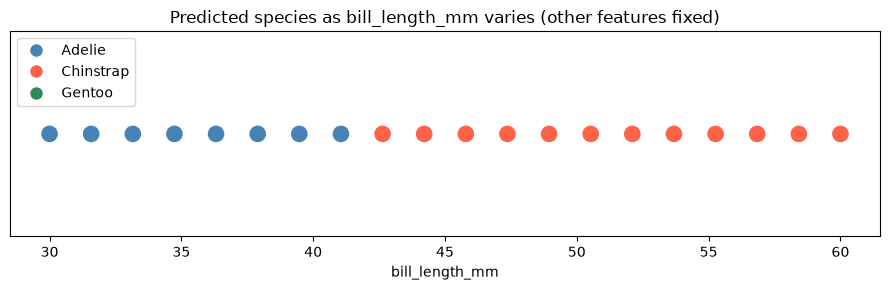

2026-08-14 00:48:09 | INFO | M07_TEJA | ANALYST CHOICE: Where does the prediction shift and does that match your expectation?


In [3]:
# === Section 3. Feature Sensitivity ===


def sweep_feature(
    base: dict[str, Any],
    feature: str,
    values: Sequence[float],
) -> pd.DataFrame:
    """Vary one feature across a range and collect predictions.

    WHY: Holding all other features fixed isolates the effect of one input.
    This is the simplest way to probe a black-box model.

    Args:
        base: baseline payload with all four features set.
        feature: the feature name to vary.
        values: list of values to try for that feature.

    Returns:
        DataFrame with columns [feature, 'prediction'].
    """
    rows = []
    for v in values:
        payload = {**base, feature: v}
        rows.append({feature: v, "prediction": predict(payload)})
    return pd.DataFrame(rows)


# Use the Adelie baseline and sweep bill_length_mm.
BASE: dict[str, Any] = BASELINES[0]
bill_lengths = list(np.linspace(30, 60, 20))
df_sweep = sweep_feature(BASE, "bill_length_mm", bill_lengths)

LOG.info("bill_length_mm sweep:")
LOG.info(df_sweep.to_string(index=False))

# Plot prediction vs feature value.
species_order = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}
colors = df_sweep["prediction"].map(color_map).fillna("gray")  # pyright: ignore[reportArgumentType]

plt.figure(figsize=(9, 3))
plt.scatter(df_sweep["bill_length_mm"], [1] * len(df_sweep), c=colors, s=120)
plt.xlabel("bill_length_mm")
plt.yticks([])
plt.title("Predicted species as bill_length_mm varies (other features fixed)")
handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[s],
        markersize=10,
        label=s,
    )
    for s in species_order
]
plt.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Where does the prediction shift and does that match your expectation?"
)

## Section 3b. MY PHASE 4 CHANGE: Compare All Four Features

The example sweeps `bill_length_mm` and then asks "which feature produces the
sharpest boundary?" - a question one sweep cannot answer.

So I reuse the example's `sweep_feature()` function on **all four** features
across their realistic ranges and rank them by two measurements:

- **changed %** - the share of swept values whose prediction differs from the
  baseline Adelie prediction. This is how much influence the feature has.
- **crossings** - how many times the predicted label flips across the sweep.
  One crossing is a clean, sharp boundary; several means the feature interacts
  with the others in a messier way.

Nothing about the API call changes. The only new idea is doing the sweep
systematically instead of once.

In [4]:
# === Section 3b. MY PHASE 4 CHANGE: Sensitivity Across All Four Features ===

# Ranges span roughly the observed min/max of each feature in the penguins
# dataset, widened slightly so a boundary near an edge is still visible.
SWEEP_RANGES: dict[str, tuple[float, float]] = {
    "bill_length_mm": (30.0, 60.0),
    "bill_depth_mm": (12.0, 22.0),
    "flipper_length_mm": (170.0, 235.0),
    "body_mass_g": (2500.0, 6500.0),
}
SWEEP_STEPS: int = 20


def summarize_sweep(df: pd.DataFrame, feature: str, baseline: str) -> dict[str, Any]:
    """Measure how much one swept feature moved the prediction.

    Args:
        df: output of sweep_feature() for this feature.
        feature: the feature name that was varied.
        baseline: the prediction for the unmodified baseline payload.

    Returns:
        One row of the sensitivity summary table.
    """
    values: list[float] = df[feature].tolist()
    preds: list[str] = df["prediction"].tolist()

    # Where consecutive predictions disagree, a boundary sits between them.
    crossings: list[str] = [
        f"{preds[i]}->{preds[i + 1]} near {(values[i] + values[i + 1]) / 2:.1f}"
        for i in range(len(preds) - 1)
        if preds[i] != preds[i + 1]
    ]
    changed_pct = 100.0 * sum(p != baseline for p in preds) / len(preds)

    return {
        "feature": feature,
        "changed_%": round(changed_pct, 1),
        "crossings": len(crossings),
        "species_seen": len(set(preds)),
        "boundaries": "; ".join(crossings) if crossings else "none",
    }


# Sweep every feature from the same Adelie baseline used in Section 3.
baseline_pred: str = predict(BASE)
LOG.info(f"Baseline prediction for the unmodified payload: {baseline_pred}")

sweeps: dict[str, pd.DataFrame] = {}
summary_rows: list[dict[str, Any]] = []

for feature, (low, high) in SWEEP_RANGES.items():
    grid_values = list(np.linspace(low, high, SWEEP_STEPS))
    sweep_df = sweep_feature(BASE, feature, grid_values)
    sweeps[feature] = sweep_df
    summary_rows.append(summarize_sweep(sweep_df, feature, baseline_pred))
    LOG.info(f"  swept {feature:<20} {low:g} to {high:g} ({SWEEP_STEPS} values)")

# Rank by influence: the feature that changes the prediction most often first.
df_sensitivity = pd.DataFrame(summary_rows).sort_values(
    "changed_%", ascending=False, ignore_index=True
)

LOG.info("Feature sensitivity ranking:")
LOG.info(df_sensitivity.to_string(index=False))

2026-08-14 00:48:10 | INFO | M07_TEJA | Baseline prediction for the unmodified payload: Adelie


2026-08-14 00:48:38 | INFO | M07_TEJA |   swept bill_length_mm       30 to 60 (20 values)


2026-08-14 00:49:04 | INFO | M07_TEJA |   swept bill_depth_mm        12 to 22 (20 values)


2026-08-14 00:49:27 | INFO | M07_TEJA |   swept flipper_length_mm    170 to 235 (20 values)


2026-08-14 00:49:52 | INFO | M07_TEJA |   swept body_mass_g          2500 to 6500 (20 values)


2026-08-14 00:49:52 | INFO | M07_TEJA | Feature sensitivity ranking:


2026-08-14 00:49:52 | INFO | M07_TEJA |           feature  changed_%  crossings  species_seen                  boundaries
   bill_length_mm       60.0          1             2 Adelie->Chinstrap near 41.8
    bill_depth_mm        0.0          0             1                        none
flipper_length_mm        0.0          0             1                        none
      body_mass_g        0.0          0             1                        none


2026-08-14 00:49:52 | INFO | M07_TEJA | Saved chart: C:\GitHub_Repo\ml-07-applied\docs\images\feature_sensitivity_teja_p4.png


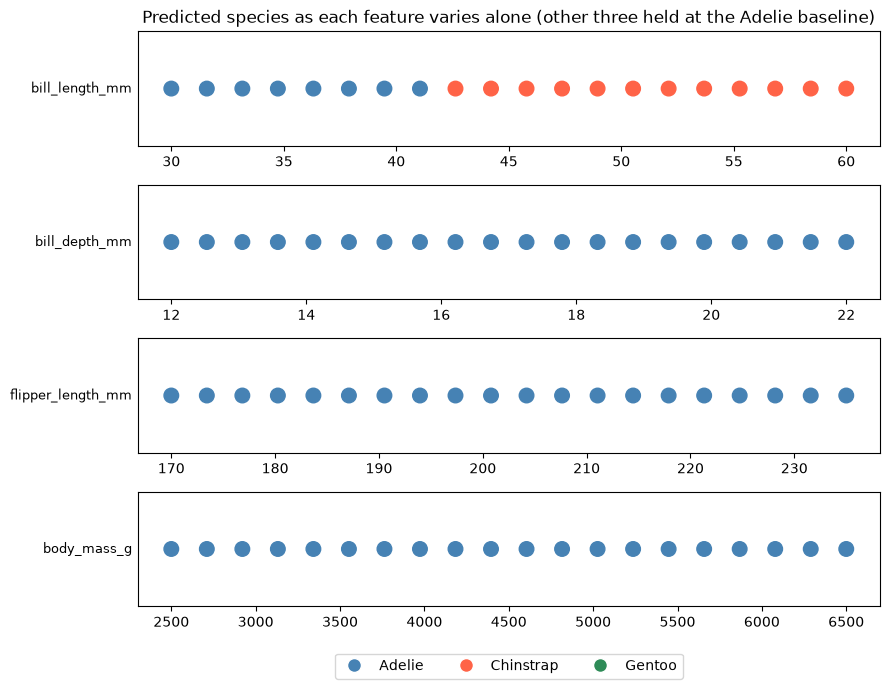

In [5]:
# === Section 3b (continued). One Strip Per Feature, Same Chart Style ===

fig, axes = plt.subplots(len(SWEEP_RANGES), 1, figsize=(9, 7))

for ax, (feature, sweep_df) in zip(axes, sweeps.items(), strict=True):
    # An unknown label (an error string) falls back to gray rather than raising.
    point_colors = [COLOR_MAP.get(p, "gray") for p in sweep_df["prediction"]]
    ax.scatter(sweep_df[feature], [1] * len(sweep_df), c=point_colors, s=110)
    ax.set_ylabel(feature, rotation=0, ha="right", va="center", fontsize=9)
    ax.set_yticks([])

handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=COLOR_MAP[s],
        markersize=10,
        label=s,
    )
    for s in SPECIES_ORDER
]
axes[0].set_title(
    "Predicted species as each feature varies alone (other three held at the Adelie baseline)"
)
axes[-1].legend(
    handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.35)
)
fig.tight_layout()

# Save for the README and docs, then display.
figure_path = IMAGES_DIR / "feature_sensitivity_teja_p4.png"
fig.savefig(figure_path, dpi=120, bbox_inches="tight")
LOG.info(f"Saved chart: {figure_path.resolve()}")
plt.show()

## What the Comparison Shows

| feature | changed % | crossings | species seen | boundary |
| --- | --- | --- | --- | --- |
| `bill_length_mm` | **60.0** | 1 | 2 | Adelie -> Chinstrap near **41.8 mm** |
| `bill_depth_mm` | 0.0 | 0 | 1 | none |
| `flipper_length_mm` | 0.0 | 0 | 1 | none |
| `body_mass_g` | 0.0 | 0 | 1 | none |

**Where does the prediction first shift away from Adelie?**
At about **41.8 mm** of bill length. The last Adelie is 41.05 mm and the first
Chinstrap is 42.63 mm, so the boundary sits between those two samples.

**Does it shift again?**
No. Chinstrap holds all the way out to 60 mm. Gentoo is never predicted at
all - no single feature, moved alone, can reach it from this baseline.

**Which feature produces the sharpest boundary?**
`bill_length_mm`, and it is not close: it is the *only* feature with a boundary,
and it is a clean one - a single crossing with no flicker on either side.

**Does that match what is known about penguins?**
Yes. In the penguins dataset Adelie have the shortest bills (around 39 mm) and
Chinstrap the longest (around 49 mm), so a threshold near 42 mm falls neatly
between the two groups. Gentoo are separated mainly by their shallow bills and
long flippers, which is consistent with never reaching Gentoo while bill depth
and flipper length are pinned at Adelie values.

## The Result Worth Naming

**Three of the four features are completely inert from this baseline.** Sweeping
bill depth across 12-22 mm, flipper length across 170-235 mm, and body mass
across 2500-6500 g never moves the prediction off Adelie - not once in 60 calls.

Inert is not the same as ignored. Section 4 shows `flipper_length_mm` pushing
the bill-length boundary from 44.1 mm out to 46.9 mm once bill length is already
near the decision. From this baseline (bill length 39.1 mm) the prediction sits
far inside Adelie territory, so the other features have nothing to tip.

That is the honest limitation of a one-feature-at-a-time sweep: it measures
**local** sensitivity at one point in feature space, not global importance. It is
also why the grid in Section 4 is worth the extra 100 calls.

## Section 4. Prediction Grid

Vary two features together and look at the 2D decision surface.

**A bug my Section 3b measurement caught.** Section 3b established that only
two species are ever reachable from this baseline: Adelie and Chinstrap, never
Gentoo. But the example's heatmap rendered large regions in **seagreen** - the
color its own title assigns to Gentoo. The cause is that the color list is
stretched across only the values actually present, so with two classes on the
grid, Chinstrap (1) takes the last color instead of the middle one.

The fix is two arguments: pin `vmin`/`vmax` so 0, 1, and 2 always land on the
same three colors whether or not all three species appear.

2026-08-14 00:52:14 | INFO | M07_TEJA | Saved chart: C:\GitHub_Repo\ml-07-applied\docs\images\prediction_grid_teja_p4.png


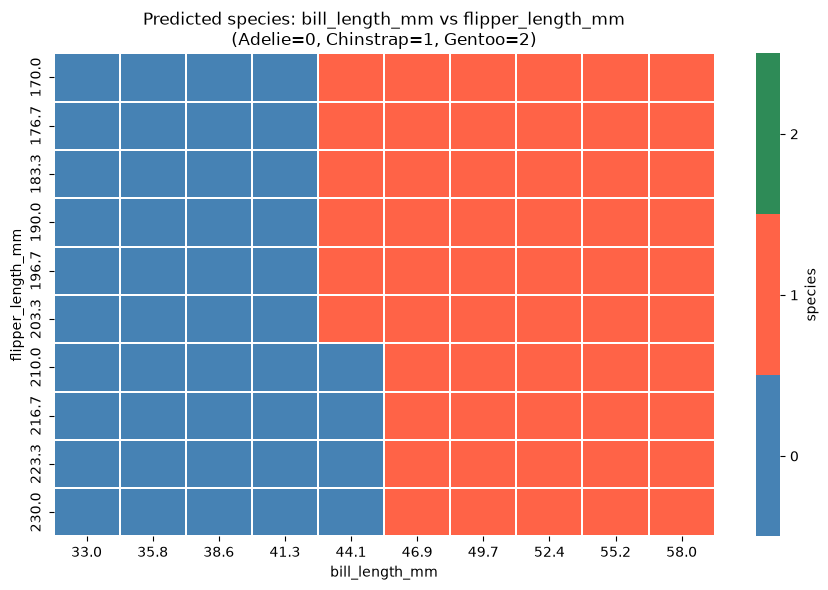

2026-08-14 00:52:15 | INFO | M07_TEJA | Species reached on the grid: Adelie, Chinstrap


2026-08-14 00:52:15 | INFO | M07_TEJA | First bill_length_mm that is no longer Adelie, per flipper_length_mm:


2026-08-14 00:52:15 | INFO | M07_TEJA |   flipper= 170.0  boundary at bill_length=44.1


2026-08-14 00:52:15 | INFO | M07_TEJA |   flipper= 176.7  boundary at bill_length=44.1


2026-08-14 00:52:15 | INFO | M07_TEJA |   flipper= 183.3  boundary at bill_length=44.1


...

2026-08-14 00:52:15 | INFO | M07_TEJA |   flipper= 203.3  boundary at bill_length=44.1


2026-08-14 00:52:15 | INFO | M07_TEJA |   flipper= 210.0  boundary at bill_length=46.9


2026-08-14 00:52:15 | INFO | M07_TEJA |   flipper= 216.7  boundary at bill_length=46.9


2026-08-14 00:52:15 | INFO | M07_TEJA |   flipper= 223.3  boundary at bill_length=46.9


2026-08-14 00:52:15 | INFO | M07_TEJA |   flipper= 230.0  boundary at bill_length=46.9


In [6]:
# === Section 4. Prediction Grid ===

# Ranges chosen from Section 3b: bill_length_mm holds the only boundary,
# so it is swept across it, with flipper_length_mm as the second axis.
bill_length_values = list(np.linspace(33, 58, 10))
flipper_length_values = list(np.linspace(170, 230, 10))

rows = []
for bl in bill_length_values:
    for fl in flipper_length_values:
        payload = {**BASE, "bill_length_mm": bl, "flipper_length_mm": fl}
        rows.append(
            {
                "bill_length_mm": round(bl, 1),
                "flipper_length_mm": round(fl, 1),
                "prediction": predict(payload),
            }
        )

df_grid = pd.DataFrame(rows)
species_to_int = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
df_grid["species_int"] = df_grid["prediction"].map(species_to_int).fillna(-1)  # pyright: ignore[reportArgumentType]

pivot = df_grid.pivot(
    index="flipper_length_mm",
    columns="bill_length_mm",
    values="species_int",
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot,
    cmap=["steelblue", "tomato", "seagreen"],
    # MY CHANGE: pin the scale so species_int 0/1/2 always map to the same
    # three colors. Without this, a grid containing only Adelie and Chinstrap
    # renders Chinstrap in seagreen, which the title labels as Gentoo.
    vmin=-0.5,
    vmax=2.5,
    linewidths=0.3,
    cbar_kws={"ticks": [0, 1, 2], "label": "species"},
)
plt.title(
    "Predicted species: bill_length_mm vs flipper_length_mm\n(Adelie=0, Chinstrap=1, Gentoo=2)"
)
plt.tight_layout()

grid_path = IMAGES_DIR / "prediction_grid_teja_p4.png"
plt.savefig(grid_path, dpi=120, bbox_inches="tight")
LOG.info(f"Saved chart: {grid_path.resolve()}")
plt.show()

# MY CHANGE: log where the boundary sits on each row, so the grid is readable
# in project.log and not only as a picture.
LOG.info(
    "Species reached on the grid: " + ", ".join(sorted(df_grid["prediction"].unique()))
)
LOG.info("First bill_length_mm that is no longer Adelie, per flipper_length_mm:")
for flipper, group in df_grid.groupby("flipper_length_mm"):
    not_adelie = group.loc[group["prediction"] != "Adelie", "bill_length_mm"]
    edge = f"{not_adelie.min():.1f}" if len(not_adelie) else "never"
    LOG.info(f"  flipper={flipper:>6.1f}  boundary at bill_length={edge}")

## Section 5. Edge Cases

What happens with unusual or invalid input? A robust API should refuse what it
cannot sensibly answer.

In [7]:
# === Section 5. Edge Cases ===

edge_cases: list[tuple[str, dict[str, Any]]] = [
    (
        "missing feature",
        {"bill_length_mm": 39.1, "bill_depth_mm": 18.7, "flipper_length_mm": 181},
    ),
    (
        "extreme bill length",
        {
            "bill_length_mm": 1.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "very large bill",
        {
            "bill_length_mm": 999.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "negative value",
        {
            "bill_length_mm": -10.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "zero body mass",
        {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 0,
        },
    ),
]

LOG.info("Edge case results:")
for label, payload in edge_cases:
    result = predict(payload)
    LOG.info(f"  {label:<22} -> {result}")

LOG.info("ANALYST CHOICE: Which edge cases were handled cleanly and which were not?")

2026-08-14 00:52:15 | INFO | M07_TEJA | Edge case results:


2026-08-14 00:52:15 | INFO | M07_TEJA |   missing feature        -> ERROR: 400 Client Error: Bad Request for url: https://ml-penguin-predictor.onrender.com/predict


2026-08-14 00:52:16 | INFO | M07_TEJA |   extreme bill length    -> Adelie


2026-08-14 00:52:17 | INFO | M07_TEJA |   very large bill        -> Chinstrap


2026-08-14 00:52:21 | INFO | M07_TEJA |   negative value         -> Adelie


2026-08-14 00:52:22 | INFO | M07_TEJA |   zero body mass         -> Adelie


2026-08-14 00:52:22 | INFO | M07_TEJA | ANALYST CHOICE: Which edge cases were handled cleanly and which were not?


## Section 6. Summary

In [8]:
# === Section 6. Summary ===


def summarize() -> None:
    """Record what was investigated and what the sweeps showed."""
    LOG.info("========================")
    LOG.info("SUMMARY")
    LOG.info("========================")
    LOG.info(f"API endpoint: {API_URL}")
    LOG.info(f"Baseline prediction: {baseline_pred}")
    LOG.info(f"Features swept: {len(SWEEP_RANGES)} x {SWEEP_STEPS} values")
    LOG.info("Feature sensitivity ranking (most influential first):")
    for row in df_sensitivity.to_dict("records"):
        LOG.info(
            f"  {row['feature']:<20} changed={row['changed_%']:>5}%  "
            f"crossings={row['crossings']}  boundaries: {row['boundaries']}"
        )
    LOG.info(f"Most influential feature: {df_sensitivity.iloc[0]['feature']}")
    LOG.info("========================")
    LOG.info("Executed successfully!")
    LOG.info("========================")


summarize()

2026-08-14 00:52:22 | INFO | M07_TEJA | ========================


2026-08-14 00:52:22 | INFO | M07_TEJA | SUMMARY


2026-08-14 00:52:22 | INFO | M07_TEJA | ========================


2026-08-14 00:52:22 | INFO | M07_TEJA | API endpoint: https://ml-penguin-predictor.onrender.com/predict


2026-08-14 00:52:22 | INFO | M07_TEJA | Baseline prediction: Adelie


...

2026-08-14 00:52:22 | INFO | M07_TEJA |   body_mass_g          changed=  0.0%  crossings=0  boundaries: none


2026-08-14 00:52:22 | INFO | M07_TEJA | Most influential feature: bill_length_mm


2026-08-14 00:52:22 | INFO | M07_TEJA | ========================


2026-08-14 00:52:22 | INFO | M07_TEJA | Executed successfully!


2026-08-14 00:52:22 | INFO | M07_TEJA | ========================


## Narrative

Investigations completed:

1. Baseline predictions confirmed - all three species correct, after the
   warm-up fix removed the false `MISMATCH`.
2. Single-feature sweep of `bill_length_mm` (the example's Section 3).
3. **My Phase 4 addition:** the same sweep applied to all four features and
   ranked by influence (Section 3b).
4. Prediction grid over `bill_length_mm` x `flipper_length_mm`, with the
   color-scale bug fixed and the boundary logged per row.
5. Edge case testing.

## Conclusions

This is **supervised** learning: the model was trained with a known target.
The target `species` is a category, so the model performs **classification**.

What the investigation showed:

- `bill_length_mm` is the dominant feature. It changed the prediction on 60% of
  its swept range; the other three changed it on 0%.
- The Adelie/Chinstrap boundary sits near **41.8 mm** from the baseline, and
  near **44-47 mm** on the grid, where the other features are also in play.
- `flipper_length_mm` is not ignored, it is just inactive far from the
  boundary. On the grid it moves the boundary by one step (44.1 -> 46.9 mm)
  for flippers of 210 mm and longer.
- The API is strict about **shape** and permissive about **values**. A missing
  field is correctly rejected with HTTP 400, but a 1 mm bill, a 999 mm bill, a
  negative bill length, and a 0 g penguin all return confident species
  predictions with no warning.

## What I Would Change About the API Contract

- **Validate ranges, not just presence.** A negative bill length is not a
  penguin; it should be a 400 like the missing field is.
- **Return the probability, not just the label.** Every response here is equally
  confident-looking, so from the outside there is no way to tell a prediction
  well inside a region from one sitting on the boundary.

## Next Steps

- Bisect around 41.8 mm to pin the boundary to a tighter interval than the
  1.6 mm sweep step allows.
- Repeat the four-feature sweep from the Chinstrap and Gentoo baselines. If
  the ranking changes, that confirms the sensitivity is local rather than a
  property of the model as a whole.
- Add bill depth as a third grid axis to find where Gentoo starts, since no
  single-feature move from the Adelie baseline ever reaches it.